In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class UserTrader(Trader):

    def __init__(self):
        self.ema = {}          # fair value per product
        self.alpha = 0.2       # EMA smoothing
        self.vol = {}          # simple volatility estimate

    def update_ema(self, product, price):
        if product not in self.ema:
            self.ema[product] = price
        else:
            self.ema[product] = self.alpha * price + (1 - self.alpha) * self.ema[product]

    def update_vol(self, product, price):
        if product not in self.vol:
            self.vol[product] = 1
        else:
            self.vol[product] = 0.8 * self.vol[product] + 0.2 * abs(price - self.ema[product])

    def run(self, state: TradingState):
        result: Dict[str, List[Order]] = {}

        for product, order_depth in state.order_depths.items():
            orders: List[Order] = []

            if not order_depth.buy_orders or not order_depth.sell_orders:
                result[product] = orders
                continue

            best_bid = max(order_depth.buy_orders.keys())
            best_ask = min(order_depth.sell_orders.keys())
            mid_price = (best_bid + best_ask) / 2

            # --- Update stats ---
            self.update_ema(product, mid_price)
            self.update_vol(product, mid_price)

            fair = self.ema[product]
            vol = max(self.vol[product], 1)  # avoid zero

            # --- Position ---
            position = state.position.get(product, 0)
            LIMIT = 20
            base_size = 5

            # --- Spread based on volatility ---
            spread = 1 + vol * 0.5

            # --- Inventory skew (VERY IMPORTANT) ---
            skew = position * 0.3

            buy_price = int(fair - spread - skew)
            sell_price = int(fair + spread - skew)

            # --- Passive MM orders ---
            if position < LIMIT:
                buy_qty = min(base_size, LIMIT - position)
                orders.append(Order(product, buy_price, buy_qty))

            if position > -LIMIT:
                sell_qty = min(base_size, LIMIT + position)
                orders.append(Order(product, sell_price, -sell_qty))

            # --- Aggressive edge-taking (alpha) ---
            # Only trade if strong deviation
            EDGE_THRESHOLD = 2 + vol

            if best_ask < fair - EDGE_THRESHOLD and position < LIMIT:
                orders.append(Order(product, best_ask, min(5, LIMIT - position)))

            if best_bid > fair + EDGE_THRESHOLD and position > -LIMIT:
                orders.append(Order(product, best_bid, -min(5, LIMIT + position)))

            result[product] = orders

        return result, 0, ""

In [7]:
backtesting_engine = Backtester("./data/prices2.csv", "./data/trades.csv")

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [8]:
sample_trader = UserTrader()
pos, pnl=backtesting_engine.run_trader(sample_trader)

In [9]:
emerald_pnl = []
tomatoes_pnl = []
total_pnl = []
for t in pnl:
    emerald_pnl.append(t["EMERALDS"])
    tomatoes_pnl.append(t["TOMATOES"])
    total_pnl.append(t["EMERALDS"]+t["TOMATOES"])

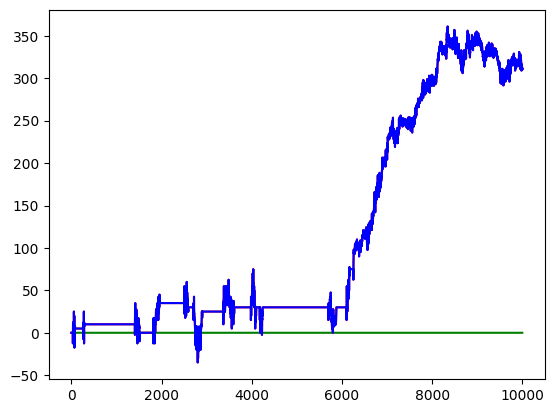

In [10]:
plt.plot([i for i in range(len(pnl))], emerald_pnl, color="green")
plt.plot([i for i in range(len(pnl))], tomatoes_pnl, color="red")

plt.plot([i for i in range(len(pnl))], total_pnl, color="blue")